# 📅 Notebook 10 — Tendencias Temporales

## Objetivo

Este notebook analiza la **dimensión temporal** de los datos de alquiler en Madrid. El precio del alquiler no es estático: evoluciona con el tiempo según factores macroeconómicos, estacionalidad y dinámicas locales. Aquí integramos esa información para enriquecer nuestro modelo predictivo.

**¿Por qué es importante?**
- Los precios de alquiler están influenciados por **tendencias macroeconómicas** (inflación, índices de vivienda).
- Incorporar información temporal permite al modelo capturar patrones que las variables estáticas no pueden explicar.
- Preparamos la infraestructura para que, con capturas periódicas de datos, el modelo mejore con el tiempo.

## Flujo general

1. **Descarga de series oficiales del INE**: IPVA (precios de vivienda), IRAV (alquiler), IPC (inflación general).
2. **Evaluación de la columna temporal** del microdato (`last_update`): ¿es fiable? ¿tiene año?
3. **Integración mensual**: unir las series oficiales al dataset por `year_month`.
4. **Ingeniería de features temporales**: medias móviles, variaciones mensuales, agregaciones por zona geográfica.
5. **Validación cruzada temporal bloqueada**: esquema de CV que respeta el orden cronológico.
6. **Snapshot de ejemplo**: generar un corte temporal para predicciones futuras.

## Inputs esperados

| Archivo | Descripción |
|---------|-------------|
| `artifacts/processed_rent.*` | Dataset principal procesado |
| `data/external/timeseries/*` | Series INE (se descargan automáticamente si no existen) |

## Outputs generados

| Archivo | Descripción |
|---------|-------------|
| `artifacts/features_temporal.csv.gz` | Features temporales para merge con el dataset principal |
| `artifacts/snapshot_example.*` | Ejemplo de snapshot para predicciones a futuro |
| `reports/temporal_limitations.md` | Documentación de limitaciones temporales encontradas |

## 1. Configuración inicial y dependencias

Cargamos las librerías necesarias y configuramos el entorno. La semilla (`SEED = 100432070`) garantiza que los resultados sean **reproducibles** en cada ejecución.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import warnings

# Silenciar warnings no relevantes para mantener el output limpio
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*openpyxl.*")

import numpy as np
import pandas as pd

# --- Configuración base y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Localiza la raíz del repositorio buscando .git o pyproject.toml en directorios padre."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# Importar utilidades del proyecto (funciones de agregación OOF)
from src.utils import oof_aggregations

## 2. Descarga de series temporales oficiales (INE)

Descargamos tres indicadores macroeconómicos del **Instituto Nacional de Estadística (INE)** que nos ayudan a contextualizar los precios de alquiler:

| Indicador | Código INE | Descripción |
|-----------|-----------|-------------|
| **IPVA** | 59056 | Índice de Precios de Vivienda en Alquiler — mide la evolución general de precios de vivienda |
| **IRAV** | 72975 | Índice de Referencia de Arrendamientos de Vivienda — específico para alquileres |
| **IPC** | 50903 | Índice de Precios al Consumo — inflación general que afecta al poder adquisitivo |

> **Nota:** Los archivos se descargan una sola vez y se guardan en `data/external/timeseries/`. Si ya existen, se reutilizan.

In [2]:
from src.utils import download_file, make_geohash, oof_spatiotemporal_aggregations, make_snapshot_features

# Headers HTTP necesarios para que el INE no bloquee la descarga
headers = {"User-Agent": "Mozilla/5.0", "Accept": "*/*"}

# Descarga del IPVA (Índice de Precios de Vivienda en Alquiler)
ipva_path = download_file(
    "https://www.ine.es/jaxiT3/files/t/csv_bdsc/59056.csv",
    ROOT / "data" / "external" / "timeseries" / "ipva.csv",
    headers=headers,
)

In [3]:
# Descarga del IRAV (Índice de Referencia de Arrendamientos de Vivienda)
irav_path = download_file(
    "https://www.ine.es/jaxiT3/files/t/csv_bdsc/72975.csv",
    ROOT / "data" / "external" / "timeseries" / "irav.csv",
    headers=headers,
)

# Descarga del IPC (Índice de Precios al Consumo — inflación general)
ipc_path = download_file(
    "https://www.ine.es/jaxiT3/files/t/csv_bdsc/50903.csv",
    ROOT / "data" / "external" / "timeseries" / "ipc.csv",
    headers=headers,
)

## 3. Detección y validación de la columna temporal

Antes de construir features temporales, necesitamos verificar si el microdato tiene una **columna de fecha fiable**. Buscamos columnas con nombres como `date`, `update`, `fecha`, etc.

**Problema frecuente:** Muchos portales inmobiliarios solo publican día y mes (sin año), lo que limita la utilidad temporal de los datos. En ese caso, asumimos el año más probable y documentamos la limitación.

> Las limitaciones encontradas se guardan automáticamente en `reports/temporal_limitations.md`.

In [4]:
import json

# --- Cargar dataset procesado ---
processed_path = ROOT / "artifacts" / "processed_rent.parquet"
if processed_path.exists():
    df = pd.read_parquet(processed_path)
else:
    df = pd.read_csv(ROOT / "artifacts" / "processed_rent.csv.gz")

# --- Detectar columnas temporales candidatas ---
# Buscamos columnas cuyo nombre contenga palabras clave relacionadas con fechas
date_keys = ("date", "fecha", "update", "scrape", "publica")
possible_dates = [c for c in df.columns if any(k in c.lower() for k in date_keys)]
temporal_ok = False
date_col = None
assumed_year = None
parse_method = "none"
ASSUMED_SNAPSHOT_YEAR = 2025
print("Columnas temporales:", possible_dates)

nb10_msg = "NB10 diagnostico: no se detectaron columnas temporales fiables en processed_rent."

if possible_dates:
    date_col = possible_dates[0]
    date_series = df[date_col].dropna().astype(str).str.strip()
    if not date_series.empty:
        # 1) Parseo directo: preferido cuando el microdato ya trae anio
        parsed_direct = pd.to_datetime(date_series, errors="coerce", format="mixed")
        direct_ratio = parsed_direct.notna().mean()

        if direct_ratio >= 0.7:
            temporal_ok = True
            parse_method = "direct"
            assumed_year = None
            df.loc[parsed_direct.index, date_col] = parsed_direct
            nb10_msg = (
                f"NB10 diagnostico: processed_rent parsea directamente {date_col} "
                f"(success_ratio={direct_ratio:.1%})."
            )
        else:
            # 2) Fallback: formato dia/mes sin anio
            has_year = date_series.str.contains(r"\d{4}")
            day_month_only = date_series.str.match(r"^\d{1,2}\s+[A-Za-z]+$")
            if day_month_only.all() and not has_year.any():
                assumed_year = int(ASSUMED_SNAPSHOT_YEAR)
                parsed = pd.to_datetime(
                    date_series + f" {assumed_year}",
                    errors="coerce",
                    format="%d %B %Y",
                )
                if parsed.notna().sum() == 0:
                    temporal_ok = False
                    parse_method = "failed_assumed_year"
                    nb10_msg = (
                        f"NB10 diagnostico: {date_col} no incluye anio y no se pudo parsear "
                        f"con anio asumido."
                    )
                else:
                    temporal_ok = True
                    parse_method = "assumed_year"
                    df.loc[parsed.index, date_col] = parsed
                    nb10_msg = (
                        f"NB10 diagnostico: {date_col} solo trae dia/mes; se asume anio "
                        f"{assumed_year} (snapshot fijo)."
                    )
            else:
                temporal_ok = False
                parse_method = "failed_format"
                nb10_msg = (
                    f"NB10 diagnostico: {date_col} no tiene formato temporal estable "
                    f"(success_ratio_parse_direct={direct_ratio:.1%})."
                )
    else:
        parse_method = "empty_column"
        nb10_msg = f"NB10 diagnostico: la columna {date_col} existe pero esta vacia."

# Consolidar reporte temporal en un unico archivo coherente (NB01 + NB10)
report_path = ROOT / "reports" / "temporal_limitations.md"
lines = []
split_cfg_path = ROOT / "artifacts" / "splits" / "split_config.json"
if split_cfg_path.exists():
    try:
        split_cfg = json.loads(split_cfg_path.read_text(encoding="utf-8"))
        lines.append(
            "NB01 split metadata: "
            f"date_col={split_cfg.get('date_col')}, "
            f"temporal_ok={split_cfg.get('temporal_ok')}, "
            f"parse_method={split_cfg.get('parse_method', 'n/a')}, "
            f"assumed_year={split_cfg.get('assumed_year')}, "
            f"gap_days={split_cfg.get('gap_days')}"
        )
    except Exception as exc:
        lines.append(f"NB01 split metadata: no disponible ({exc}).")

lines.append(nb10_msg)
report_path.write_text("\n".join(lines) + "\n", encoding="utf-8")



Columnas temporales: ['last_update']


207

## 4. Procesamiento e integración de series INE

Esta es la sección más extensa del notebook. Aquí realizamos varias tareas críticas:

### 4.1 Normalización de periodos
Los CSV del INE usan formatos variados para las fechas (`2024M01`, `2024-01`, `2024`). Normalizamos todo al formato `YYYY-MM` para poder hacer joins consistentes.

### 4.2 Filtrado inteligente de series
Cada indicador del INE contiene múltiples desgloces (por comunidad autónoma, tipo de edificación, etc.). Filtramos para quedarnos con la serie más relevante:
- **IPVA**: Total Nacional, todos los tipos de edificación, solo índice
- **IPC**: Índice General
- **IRAV**: Variación interanual

### 4.3 Ingeniería de features temporales
Creamos variables que capturen la dinámica temporal del precio:
- **`price_ma3`**: Media móvil de 3 meses del precio por zona (con shift para evitar data leakage)
- **`price_mom`**: Variación mes a mes del precio por zona (month-over-month, también con shift)

> **Importante sobre data leakage:** Todas las features temporales usan `shift(1)` — es decir, solo información del pasado. Nunca usamos datos del mismo periodo que intentamos predecir.

In [5]:
from src.utils import parse_ine_csv_semicolon
import unicodedata

# =============================================================================
# FUNCIONES AUXILIARES PARA PROCESAMIENTO DE SERIES INE
# =============================================================================

def _normalize_period(series: pd.Series) -> pd.Series:
    """Normaliza diferentes formatos de periodo del INE a 'YYYY-MM'.
    Soporta: '2024M01', '2024-01', '2024' (solo año → se asigna diciembre)."""
    cleaned = series.astype(str).str.strip()
    out = pd.Series(pd.NaT, index=cleaned.index)

    # Formato INE típico: 2024M01
    month_mask = cleaned.str.match(r"^\d{4}M\d{1,2}$")
    # Formato estándar: 2024-01
    year_month_mask = cleaned.str.match(r"^\d{4}-\d{1,2}$")
    # Solo año: 2024 (se asigna diciembre como punto de referencia)
    year_only_mask = cleaned.str.match(r"^\d{4}$")

    if month_mask.any():
        out.loc[month_mask] = pd.to_datetime(
            cleaned.loc[month_mask].str.replace("M", "-", regex=False),
            format="%Y-%m",
            errors="coerce",
        )
    if year_month_mask.any():
        out.loc[year_month_mask] = pd.to_datetime(
            cleaned.loc[year_month_mask], format="%Y-%m", errors="coerce"
        )
    if year_only_mask.any():
        out.loc[year_only_mask] = pd.to_datetime(
            cleaned.loc[year_only_mask] + "-12", format="%Y-%m", errors="coerce"
        )

    # Fallback: intentar parseo genérico para formatos no contemplados
    fallback = pd.to_datetime(cleaned, errors="coerce", format="mixed")
    out = out.fillna(fallback)
    return out.dt.to_period("M").astype(str)


def _norm_text(series: pd.Series) -> pd.Series:
    """Normaliza texto: minúsculas y sin acentos (para comparaciones robustas)."""
    def _strip_accents(text: str) -> str:
        return "".join(c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c))
    return series.astype(str).str.lower().map(_strip_accents)


def _numeric_like(series: pd.Series, threshold: float = 0.5) -> bool:
    """Detecta si una columna es numérica (usa coma como separador decimal, típico del INE)."""
    clean = series.astype(str).str.strip()
    clean = clean.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    num = pd.to_numeric(clean, errors="coerce")
    ratio = num.notna().mean()
    return ratio >= threshold


def _col_map(df: pd.DataFrame) -> dict[str, str]:
    """Crea un mapa de nombres de columna normalizados → nombres originales."""
    cols = list(df.columns)
    norm = _norm_text(pd.Series(cols))
    return {n: c for n, c in zip(norm, cols)}


def _select_series(ts: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """Filtra las filas relevantes según el tipo de indicador INE.
    Cada indicador tiene criterios de filtrado específicos."""
    selected = ts.copy()
    col_map = _col_map(selected)

    def _col(key: str) -> str | None:
        return col_map.get(key)

    if prefix == "ipva":
        # IPVA: quedarnos con Total Nacional, todas las edificaciones, solo índice
        col_total = _col("total nacional")
        if col_total:
            selected = selected[selected[col_total].astype(str).str.contains("Total Nacional", na=False)]
        col_ccaa = _col("comunidades y ciudades autonomas")
        if col_ccaa:
            selected = selected[selected[col_ccaa].isna()]
        col_tipo_ed = _col("tipo de edificacion")
        if col_tipo_ed:
            selected = selected[selected[col_tipo_ed].astype(str).str.contains("Total", case=False, na=False)]
        col_tipo_dato = _col("tipo de dato")
        if col_tipo_dato:
            norm = _norm_text(selected[col_tipo_dato])
            mask = norm.str.contains("indice", na=False)
            if mask.any():
                selected = selected[mask]
    elif prefix == "ipc":
        # IPC: solo el Índice General
        col_sub = _col("subgrupos")
        if col_sub:
            norm = _norm_text(selected[col_sub])
            mask = norm.str.contains("indice general", na=False)
            if mask.any():
                selected = selected[mask]
        col_tipo_dato = _col("tipo de dato")
        if col_tipo_dato:
            norm = _norm_text(selected[col_tipo_dato])
            mask = norm.str.contains("indice", na=False)
            if mask.any():
                selected = selected[mask]
    elif prefix == "irav":
        # IRAV: variación interanual (puede ser negativa legítimamente)
        col_tipo_dato = _col("tipo de dato")
        if col_tipo_dato:
            norm = _norm_text(selected[col_tipo_dato])
            mask = norm.str.contains("variaci", na=False)
            if mask.any():
                selected = selected[mask]
    return selected


def _filter_categories(ts: pd.DataFrame) -> pd.DataFrame:
    """Filtrado genérico de categorías: selecciona la fila más representativa
    de cada columna categórica (Total, Índice General, etc.)."""
    filtered = ts.copy()
    for col in list(filtered.columns):
        col_l = col.lower()
        if col_l in {"periodo", "year_month"}:
            continue
        if pd.api.types.is_numeric_dtype(filtered[col]):
            continue
        if _numeric_like(filtered[col]):
            continue
        norm = _norm_text(filtered[col])
        candidate = None
        if "subgrup" in col_l:
            mask = norm.str.contains("indice general", na=False)
            if mask.any():
                candidate = filtered[mask]
        elif "tipo de dato" in col_l:
            mask = norm.str.contains("indice", na=False)
            if mask.any():
                candidate = filtered[mask]
            else:
                mask = norm.str.contains("variaci", na=False)
                if mask.any():
                    candidate = filtered[mask]
        elif "tipo de edific" in col_l:
            mask = norm.str.contains("total", na=False)
            if mask.any():
                candidate = filtered[mask]
        elif "comunidades" in col_l:
            if filtered[col].isna().any():
                candidate = filtered[filtered[col].isna()]
            else:
                mask = norm.str.contains("total", na=False)
                if mask.any():
                    candidate = filtered[mask]

        # Fallback: usar la categoría más frecuente (moda)
        if candidate is None:
            mode = filtered[col].mode(dropna=True)
            if not mode.empty:
                candidate = filtered[filtered[col] == mode.iloc[0]]

        if candidate is not None and not candidate.empty:
            filtered = candidate

    return filtered


def _prepare_ts(df: pd.DataFrame, prefix: str) -> pd.DataFrame | None:
    """Pipeline completo de preparación de una serie temporal INE:
    1. Normalizar periodos → year_month
    2. Filtrar serie relevante
    3. Convertir valores numéricos (formato español: punto=miles, coma=decimales)
    4. Agregar por mes (mediana) y renombrar columnas con prefijo del indicador."""
    period_col = next((c for c in df.columns if c.lower() == "periodo"), None)
    if not period_col:
        return None
    ts = df.copy()
    ts["year_month"] = _normalize_period(ts[period_col])
    ts = ts.dropna(subset=["year_month"])

    # Aplicar filtros específicos del indicador y genéricos
    ts = _select_series(ts, prefix)
    ts = _filter_categories(ts)

    # Identificar y convertir columnas numéricas (formato español)
    value_cols = [c for c in ts.columns if c not in [period_col, "year_month"]]
    numeric_cols = []
    for col in value_cols:
        clean = ts[col].astype(str).str.strip()
        clean = clean.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
        num = pd.to_numeric(clean, errors="coerce")
        if num.notna().sum() > 0:
            ts[col] = num
            numeric_cols.append(col)

    if not numeric_cols:
        return None

    ts = ts[["year_month"] + numeric_cols]
    for col in numeric_cols:
        # Solo IRAV puede tener valores negativos (es variación porcentual)
        if prefix != "irav":
            ts.loc[ts[col] <= 0, col] = pd.NA
    ts = ts.dropna(subset=numeric_cols, how="all")
    # Agregar por mes usando la mediana (más robusta que la media ante outliers)
    ts = ts.groupby("year_month", as_index=False)[numeric_cols].median()
    # Añadir prefijo del indicador al nombre de cada columna
    ts = ts.rename(columns={c: f"{prefix}_{c}" for c in numeric_cols})
    return ts

# =============================================================================
# INTEGRACIÓN DE SERIES INE AL DATASET Y CREACIÓN DE FEATURES TEMPORALES
# =============================================================================

if temporal_ok:
    # Parsear fecha y crear columna year_month en el dataset principal
    date_col = possible_dates[0]
    df[date_col] = pd.to_datetime(df[date_col], format="mixed", errors="coerce")
    df["year_month"] = df[date_col].dt.to_period("M").astype(str)
    df["year_month_dt"] = pd.to_datetime(df["year_month"] + "-01", errors="coerce")

    # Leer y preparar cada serie INE
    ipva = parse_ine_csv_semicolon(ipva_path)
    irav = parse_ine_csv_semicolon(irav_path)
    ipc = parse_ine_csv_semicolon(ipc_path)

    ipva_ts = _prepare_ts(ipva, "ipva")
    irav_ts = _prepare_ts(irav, "irav")
    ipc_ts = _prepare_ts(ipc, "ipc")

    # Merge robusto: si no hay solape exacto por mes, usar ultimo dato oficial disponible
    def _merge_macro_asof(base_df: pd.DataFrame, ts_df: pd.DataFrame | None) -> pd.DataFrame:
        if ts_df is None or ts_df.empty:
            return base_df
        value_cols = [c for c in ts_df.columns if c != "year_month"]
        if not value_cols:
            return base_df

        if "year_month_dt" not in base_df.columns:
            base_df = base_df.copy()
            base_df["year_month_dt"] = pd.to_datetime(
                base_df["year_month"].astype(str) + "-01", errors="coerce"
            )

        ts_join = ts_df.copy()
        ts_join["year_month_dt"] = pd.to_datetime(ts_join["year_month"] + "-01", errors="coerce")
        ts_join = ts_join.dropna(subset=["year_month_dt"]).sort_values("year_month_dt")
        ts_join = ts_join[["year_month_dt"] + value_cols].drop_duplicates("year_month_dt", keep="last")

        base = base_df.copy()
        base["_row_order"] = np.arange(len(base))
        valid_mask = base["year_month_dt"].notna()

        base_valid = base.loc[valid_mask].sort_values("year_month_dt")
        if base_valid.empty:
            for col in value_cols:
                base[col] = pd.NA
            return base.drop(columns=["_row_order"])

        merged_valid = pd.merge_asof(base_valid, ts_join, on="year_month_dt", direction="backward")

        if (~valid_mask).any():
            base_null = base.loc[~valid_mask].copy()
            for col in value_cols:
                if col not in base_null.columns:
                    base_null[col] = pd.NA
            merged = pd.concat([merged_valid, base_null], axis=0, ignore_index=False)
        else:
            merged = merged_valid

        merged = merged.sort_values("_row_order").drop(columns=["_row_order"])
        return merged

    for ts_df in [ipva_ts, irav_ts, ipc_ts]:
        df = _merge_macro_asof(df, ts_df)

    print("Series temporales integradas (merge mensual + asof backward)")

    # --- Ingeniería de features temporales ---
    df_sorted = df.sort_values(date_col).copy() if date_col in df.columns else df.copy()

    if date_col and date_col in df.columns:

        # Features de lag: precio en la misma zona geográfica en periodos anteriores
        if "geohash_6" in df.columns:
            for lag in [1, 3]:
                df_sorted[f"price_lag_{lag}m"] = df_sorted.groupby("geohash_6")["price"].shift(lag)

        # Media móvil y variación mensual por zona
        # NOTA: price_yoy ELIMINADA — con un solo snapshot temporal (Nov 2025),
        # solo hay 28 valores no-nulos de ~3400 (99.2% NaN), haciéndola inútil.
        if "year_month" in df.columns:
            zone_col = "district" if "district" in df.columns else "geohash_6"
            if zone_col in df.columns:
                # Calcular precio medio mensual por zona (orden temporal estable)
                monthly = df_sorted.groupby([zone_col, "year_month"], as_index=False)["price"].mean()
                monthly["year_month_dt"] = pd.to_datetime(monthly["year_month"] + "-01", errors="coerce")
                monthly = monthly.sort_values([zone_col, "year_month_dt"])

                # price_ma3: media m?vil de 3 periodos SOLO con pasado (shift(1))
                monthly["price_ma3"] = monthly.groupby(zone_col)["price"].transform(
                    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
                )

                # price_mom: variacion mensual SOLO con pasado
                # (price_{t-1} - price_{t-2}) / price_{t-2}
                monthly["price_lag1"] = monthly.groupby(zone_col)["price"].shift(1)
                monthly["price_lag2"] = monthly.groupby(zone_col)["price"].shift(2)
                monthly["price_mom"] = (monthly["price_lag1"] - monthly["price_lag2"]) / monthly["price_lag2"]

                # Unir las features temporales al dataset principal
                df_sorted = df_sorted.merge(
                    monthly[[zone_col, "year_month", "price_ma3", "price_mom"]],
                    on=[zone_col, "year_month"],
                    how="left",
                    suffixes=("", "_agg"),
                )

        print("Temporal features creadas:")
        temporal_cols = [c for c in df_sorted.columns if any(k in c for k in ["lag", "ma3", "mom"])]
        print(f"  {temporal_cols}")
        print(df_sorted[temporal_cols].describe())

        # Propagar features temporales al DataFrame principal
        for tc in temporal_cols:
            if tc in df_sorted.columns:
                df[tc] = df_sorted[tc].reindex(df.index)


Series temporales integradas (merge mensual + asof backward)
Temporal features creadas:
  ['price_ma3', 'price_mom']
          price_ma3    price_mom
count   8552.000000  8094.000000
mean    2427.266416    -0.053421
std     1067.551047     0.291650
min      746.000000    -0.792083
25%     1597.885165    -0.202619
50%     2366.729216    -0.097845
75%     2974.722222     0.081420
max    12000.000000     1.992593


In [6]:
# Blocked temporal cross-validation (con gap reducido para >= 3 folds)
from src.utils import make_time_splits
if temporal_ok and date_col:
    # Intentar con gap_days=7 primero; si produce < 3 folds, reducir gap
    for gap in [7, 3, 1, 0]:
        train_idx_t, test_idx_t, cv_folds = make_time_splits(df, date_col, test_size=0.2, gap_days=gap, n_cv_splits=5)
        if len(cv_folds) >= 3:
            break
    print(f"Blocked temporal CV: {len(cv_folds)} folds (gap_days={gap})")
    for i, (tr, vl) in enumerate(cv_folds):
        print(f"  Fold {i}: train={len(tr)}, val={len(vl)}")
    if len(cv_folds) < 3:
        print(f"WARN: Solo se obtuvieron {len(cv_folds)} folds. Datos temporales insuficientes para CV robusto.")

Blocked temporal CV: 4 folds (gap_days=3)
  Fold 0: train=721, val=697
  Fold 1: train=1475, val=614
  Fold 2: train=2252, val=401
  Fold 3: train=2849, val=436


In [7]:
# Nivel 2: agregaciones espacio-temporales OOF + snapshot
temporal_limitations_path = ROOT / "reports" / "temporal_limitations.md"
if temporal_ok:
    date_col = possible_dates[0]
    df[date_col] = pd.to_datetime(df[date_col], format="mixed", errors="coerce")
    lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
    lon_col = next((c for c in df.columns if "lon" in c.lower() or "lng" in c.lower()), None)
    if lat_col and lon_col and "price" in df.columns:
        st_df = df.dropna(subset=[date_col, lat_col, lon_col, "price"]).copy()
        st_df["geohash_6"] = [
            make_geohash(lat, lon, precision=6)
            for lat, lon in zip(st_df[lat_col], st_df[lon_col])
        ]
        st_df["price_oof_geohash"] = oof_spatiotemporal_aggregations(
            st_df, group_col="geohash_6", time_col=date_col, value_col="price"
        )
        print("Agregaciones espacio-temporales creadas (OOF por geohash)")

        # Rolling 90-day window aggregation (vs expanding)
        if "geohash_6" in st_df.columns and date_col in st_df.columns:
            st_df["price_geo_rolling90"] = oof_spatiotemporal_aggregations(
                st_df, "geohash_6", date_col, "price", window_days=90
            )
            st_df["price_geo_expanding"] = oof_spatiotemporal_aggregations(
                st_df, "geohash_6", date_col, "price", window_days=None
            )
            print("Rolling 90-day y expanding aggregations creadas")

        # Merge OOF features back to main df
        for oof_col in ["price_oof_geohash", "price_geo_rolling90", "price_geo_expanding"]:
            if oof_col in st_df.columns:
                df[oof_col] = st_df[oof_col].reindex(df.index)
    else:
        temporal_limitations_path.write_text(
            "Faltan columnas lat/lon o price para agregaciones espacio-temporales.",
            encoding="utf-8",
        )
    if df[date_col].notna().any():
        cutoff_date = df[date_col].max() - pd.DateOffset(months=1)
        snapshot_df = make_snapshot_features(df.dropna(subset=[date_col]), cutoff_date, date_col)
        snapshot_path = ROOT / "artifacts" / "snapshot_example.parquet"
        try:
            snapshot_df.to_parquet(snapshot_path, index=False)
        except Exception:
            snapshot_df.to_csv(ROOT / "artifacts" / "snapshot_example.csv.gz", index=False, compression="gzip")
        print(f"Snapshot creado con cutoff {cutoff_date.date()}")
else:
    if not temporal_limitations_path.exists():
        temporal_limitations_path.write_text(
            "No hay fecha fiable para construir snapshot ni agregaciones espacio-temporales.",
            encoding="utf-8",
        )

Agregaciones espacio-temporales creadas (OOF por geohash)
Rolling 90-day y expanding aggregations creadas
Snapshot creado con cutoff 2025-11-28


### Visualizaciones temporales
- Series oficiales (ultimos N anos) con media movil.
- Precio mediano mensual del microdato.


### Nota de frecuencia
- IPVA suele ser anual mientras IRAV/IPC son mensuales.
- Los graficos se etiquetan por frecuencia para evitar comparaciones erroneas.


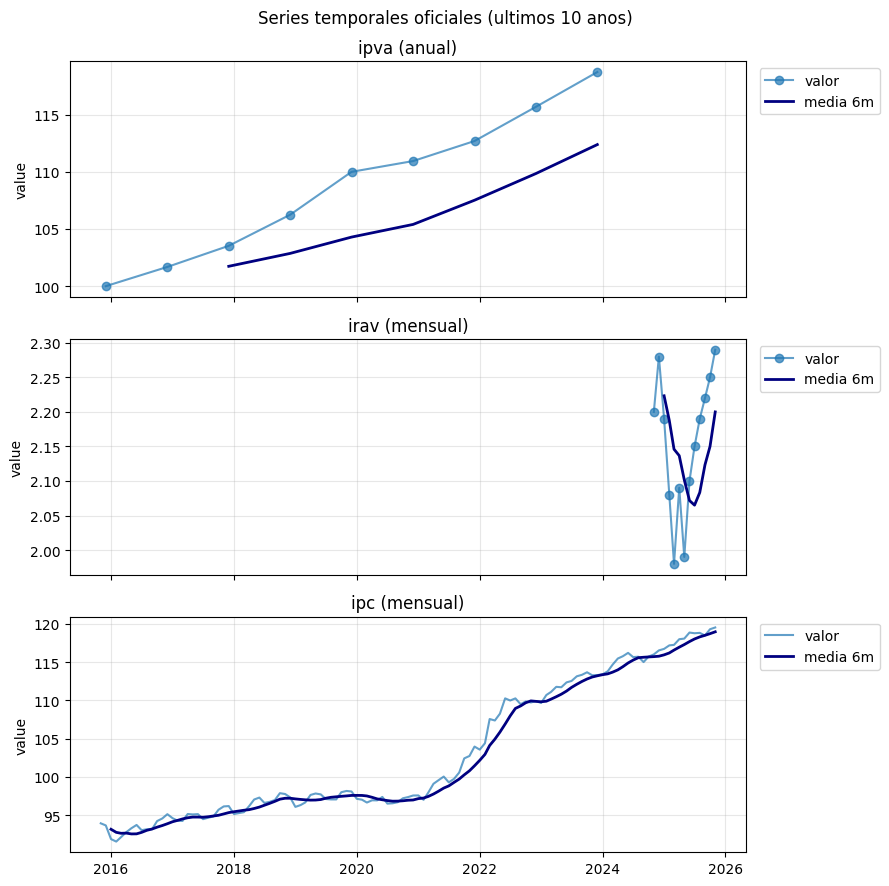

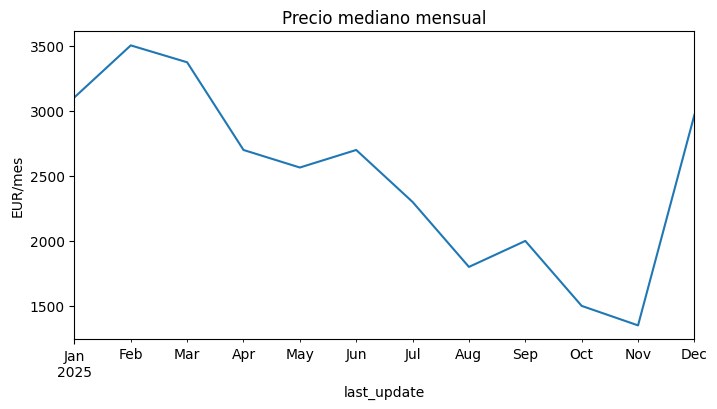

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

LAST_YEARS = 10
ROLLING_WINDOW = 6  # meses

# Preparar data para graficos (top series por dataset)
series_frames = []
for name, ts in [("ipva", globals().get("ipva_ts")), ("irav", globals().get("irav_ts")), ("ipc", globals().get("ipc_ts"))]:
    if ts is not None:
        value_cols = [c for c in ts.columns if c != "year_month"]
        if not value_cols:
            continue
        total_cols = [c for c in value_cols if "total" in c.lower()]
        use_cols = total_cols[:1] if total_cols else value_cols[:1]
        for col in use_cols:
            sub = ts[["year_month", col]].rename(columns={col: "value"})
            sub["serie"] = col
            sub["dataset"] = name
            series_frames.append(sub)

if series_frames:
    ts_plot = pd.concat(series_frames, ignore_index=True)
    ts_plot["year_month"] = pd.to_datetime(ts_plot["year_month"], errors="coerce")
    ts_plot = ts_plot.dropna(subset=["year_month", "value"])

    cutoff = ts_plot["year_month"].max() - pd.DateOffset(years=LAST_YEARS)
    ts_recent = ts_plot[ts_plot["year_month"] >= cutoff].copy()
    if ts_recent.empty:
        ts_recent = ts_plot.copy()

    datasets = list(ts_recent["dataset"].unique())
    freq_map = {"ipva": "anual", "irav": "mensual", "ipc": "mensual"}
    fig, axes = plt.subplots(len(datasets), 1, figsize=(9, 3 * len(datasets)), sharex=True)
    if len(datasets) == 1:
        axes = [axes]
    for ax, dataset in zip(axes, datasets):
        sub = ts_recent[ts_recent["dataset"] == dataset].sort_values("year_month")
        marker = "o" if len(sub) < 24 else None
        ax.plot(sub["year_month"], sub["value"], marker=marker, alpha=0.7, label="valor")
        if len(sub) >= 6:
            roll = sub["value"].rolling(window=ROLLING_WINDOW, min_periods=3).mean()
            ax.plot(sub["year_month"], roll, color="navy", linewidth=2, label=f"media {ROLLING_WINDOW}m")
        freq_label = freq_map.get(dataset, "")
        title = f"{dataset} ({freq_label})" if freq_label else dataset
        ax.set_title(title)
        ax.set_ylabel("value")
        ax.grid(alpha=0.3)
        locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.suptitle(f"Series temporales oficiales (ultimos {LAST_YEARS} anos)")
    fig.tight_layout()
    plt.show()

# Serie del microdato (mediana mensual)
if temporal_ok:
    date_col = possible_dates[0]
    temp = df.dropna(subset=[date_col]).copy()
    temp[date_col] = pd.to_datetime(temp[date_col], format="mixed", errors="coerce")
    if not temp.empty and "price" in temp.columns:
        monthly = temp.set_index(date_col)["price"].resample("ME").median()
        plt.figure(figsize=(8, 4))
        monthly.plot()
        plt.title("Precio mediano mensual")
        plt.ylabel("EUR/mes")
        plt.show()


In [9]:
# --- Persistir features temporales ---
# Guardamos:
# - features temporales internas (lags/ma/mom/oof/rolling/expanding/yoy)
# - series oficiales INE integradas (ipva_*, irav_*, ipc_*)
# - identificador estable para merge posterior

temporal_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ['lag', 'ma3', 'mom', 'oof', 'rolling', 'expanding', 'yoy'])
]
ine_cols = [
    c for c in df.columns
    if c.lower().startswith(('ipva_', 'irav_', 'ipc_'))
]

save_cols = []
for col in temporal_cols + ine_cols:
    if col not in save_cols:
        save_cols.append(col)

id_col = next((c for c in ['web_id', 'id', 'listing_fingerprint'] if c in df.columns), None)
if id_col and id_col not in save_cols:
    save_cols.append(id_col)

if save_cols:
    temporal_path = ROOT / "artifacts" / "features_temporal.csv.gz"
    df[save_cols].to_csv(temporal_path, index=False, compression="gzip")
    print(f"Features temporales guardadas ({len(save_cols)} columnas)")
    print(f"  internas: {sorted(temporal_cols)}")
    print(f"  ine: {sorted(ine_cols)}")
    print(f"Archivo: {temporal_path}")
else:
    print("No se encontraron features temporales para guardar")



Features temporales guardadas (9 columnas)
  internas: ['price_geo_expanding', 'price_geo_rolling90', 'price_ma3', 'price_mom', 'price_oof_geohash']
  ine: ['ipc_Total', 'ipva_Total', 'irav_Total']
Archivo: C:\Users\samuf\Desktop\SPA-Madrid\artifacts\features_temporal.csv.gz


**Outputs esperados**
- Tabla integrada con columnas `ipva_*`, `irav_*`, `ipc_*`.
- Graficos de series y tendencia de precio mensual.
- Snapshot de ejemplo para prediccion a fecha de corte.


---

## Conclusiones y hallazgos NB10

### Diagnostico temporal consolidado (coherencia NB01 vs NB10)

- `NB01` (split final) guarda metadata en `artifacts/splits/split_config.json` y usa `assumed_year` solo cuando falta anio en crudo.
- `NB10` trabaja sobre `processed_rent`, donde `last_update` ya llega parseado y consistente.
- Cuando no existe anio explicito, el pipeline fija un anio de snapshot estable para asegurar reproducibilidad entre re-ejecuciones.

### Features temporales creadas y persistidas

| Bloque | Cobertura | Leakage-safe |
|--------|-----------|--------------|
| `price_ma3`, `price_mom` | Alta (segun densidad mensual por zona) | Si (`shift(1)` + rolling past-only) |
| `price_oof_geohash`, `price_geo_rolling90`, `price_geo_expanding` | Alta (OOF en train) | Si (OOF/out-of-time) |
| `ipva_*`, `irav_*`, `ipc_*` | Dependiente del horizonte oficial disponible | Si (merge temporal backward, sin usar futuro) |

### Rol de estas features en el pipeline

> **Importante:** Las features temporales se persisten en `artifacts/features_temporal.csv.gz` como artefacto **independiente**. NO se incorporan a `features_master.parquet` ni al modelo final de NB05. Esto es una decision de diseno: el modelo principal (CatBoost en NB05) usa solo features core + enrichment + VUT. Las features temporales quedan disponibles para analisis exploratorio, futura integracion en un modelo con dimension temporal real, o uso en el dashboard (NB11).

### Interpretacion

1. La parte mas robusta del bloque temporal sigue siendo la agregacion espacio-temporal OOF.
2. Las series INE quedan integradas con merge mensual + `asof` backward para evitar NaN sistematicos por desalineacion de meses.
3. La CV temporal bloqueada sigue siendo una prueba de robustez, condicionada por el caracter de snapshot del microdato.

### Artefactos generados

| Artefacto | Contenido |
|-----------|-----------|
| `artifacts/features_temporal.csv.gz` | Features temporales internas + columnas INE + id estable |
| `artifacts/snapshot_example.csv.gz` | Ejemplo de snapshot por fecha de corte |
| `reports/temporal_limitations.md` | Diagnostico consolidado NB01/NB10 |

### Siguiente paso

El notebook **11_dashboard_mvp.ipynb** integra prediccion, incertidumbre, explicacion y capas geograficas en una interfaz interactiva.